# ForceGNN Usage Example

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.


In [2]:
# Import everything from the module
import sys
sys.path.append('..')

import importlib

import torch_inference_FintDot
importlib.reload(torch_inference_FintDot)
from torch_inference_FintDot import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


## Step 1: Load and Prepare Data


In [3]:
# Load data, change to your own path
datadir = "//Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Data_CSVs/"
datadir_out = "/Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/ForDuke/Experiment_Inference/Data_CSVs/"
dataname = 'master_tracks.csv'
data2 = load_data(datadir, dataname)
print(data2['condition'].unique)

SampleID = '1-2Pulse1' #'1-5Pulse6' #
data = data2[data2['sample_id']==SampleID]
print(f"Data loaded: {data2.shape}")
data['particle'] = data['track_id']
data['frame'] = data['t']
# re-index the frame to be 0,1,2,3...
print("max frame",np.max(data['frame']))
IndexFrame = data.frame.unique()
IndexFrame.sort()
data['frame'] = data['frame'].map(dict(zip(IndexFrame, range(len(IndexFrame)))))
print(data.frame.unique())
data = data.sort_values(by='frame')
data = data.sort_values(by='particle').reset_index(drop=True)
print(data.frame.unique())
CellInd = data.index[data['particle'].diff().ne(0)].tolist()
# Add the last index to the list to cover the final group
CellInd.append(len(data) - 1) #filtered_file_ids = ['circle1_offset_23', 'circle2_offset_23', 'circle3_offset_23', 'circle4_offset_23']
print(len(CellInd))

simplified = data[['particle', 'frame', 'x', 'y']]
outname = dataname.replace('.csv', '_'+str(SampleID)+'.csv')
simplified.to_csv(datadir_out + outname, index=False)
print(f"Saved: {datadir_out + outname}  ({simplified.shape[0]} rows)")
# # re-index the frame to be 0,1,2,3...

Data loaded: (1230191, 9)
Columns: ['condition', 'sample_id', 'track_id', 't', 'y', 'x', 'id', 'parent_track_id', 'parent_id']
<bound method Series.unique of 0          1-2Pulse
1          1-2Pulse
2          1-2Pulse
3          1-2Pulse
4          1-2Pulse
             ...   
1230186     Control
1230187     Control
1230188     Control
1230189     Control
1230190     Control
Name: condition, Length: 1230191, dtype: object>
Data loaded: (1230191, 9)
max frame 719.0
[  3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20
  21  22  23  24  25  26  27  28  29  30  31  32   0   1   2  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130

/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_75930/2989989730.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['particle'] = data['track_id']
/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_75930/2989989730.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['frame'] = data['t']
/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_75930/2989989730.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

[ 27   5  18  14  16  26  25  31  15  13  23  24  29  17  28  30  19  12
   8  22   7   9  11   4  20  21  32   6  10   3   1   0   2  34  39  36
  42  33  45  37  40  38  43  41  35  44  54  67  48  52  66  68  65  53
  64  62  55  61  60  50  47  57  49  58  63  56  46  59  51  69  70  99
  96 118  78  80 101  75 105 112 103  74  77  84  76  97 116 115 104  94
  79 114  89 117 113  88 106 108 121 123  87 124 125 120 109  93  92  86
  95  91 122 100  82  72 107  83 110 111  73 119 102  71  98 126  81  90
  85 133 143 134 142 141 135 136 137 139 140 138 129 130 131 128 127 132
 262 265 267 266 245 263 264 261 255 260 248 249 250 251 252 259 258 257
 256 247 254 253 269 282 281 283 280 284 287 285 268 279 273 272 288 271
 270 274 275 278 277 276 246 243 197 158 196 195 194 193 159 198 191 190
 189 160 188 192 187 199 200 209 154 208 207 206 155 205 204 156 203 244
 202 201 157 172 171 170 169 173 168 163 166 164 165 167 174 162 175 186
 185 184 183 182 181 180 179 161 178 177 176 210 28

Number of cells =  4553


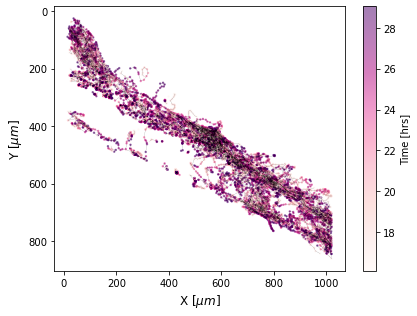

In [4]:
# first plot all the cells
fig,ax = plt.subplots(1,figsize=(6,4.5))
print("Number of cells = ",len(CellInd)-1)
count=0
CellNumCh =len(CellInd)
counter2 = 0
for cell in range(1000): #len(CellInd)-1 #00
    ci = cell #*12
    #ci = np.random.randint(0, len(CellInd)-1)
    Tstart = CellInd[ci]+1
    Tend = CellInd[ci+1]
    #print("Tstart, Tend:", Tstart, Tend)
    MaxTime = data.frame.max()
    #print("Max time:", MaxTime)
    trajectory_data = data.iloc[Tstart:Tend]
    #print("Trajectory data shape:", trajectory_data)
    trajectory_data = trajectory_data.sort_values(by='frame')
    #only take first 50 frames
    #trajectory_data = trajectory_data[trajectory_data['frame'] > 50]
    #trajectory_data = trajectory_data[trajectory_data['frame'] < 150]
    if len(trajectory_data.frame.unique()) != len(trajectory_data.frame):
        #print('Skipping cell',cell)
        counter2 +=1
        continue
    count+=1
    line = ax.plot(
        trajectory_data.x, 
        trajectory_data.y, 
        color='black',  # Set the color of the line
        linewidth=0.1,  # Set the line width
        linestyle='-',  # Set the line style
    )
    sc = ax.scatter(
        trajectory_data.x, 
        trajectory_data.y, 
        #c = clrs[cell],
        label = cell,
        c=trajectory_data.frame*0.166,  # Use EDGE_TIME for color mapping
        cmap='RdPu',  # Set the colormap
        s=2,  # Set marker size
        alpha = 0.5,
    )

plt.colorbar(sc, ax=ax, label='Time [hrs]')
# ax.set_xticks([0,200,400,600],fontsize = 12)
# ax.set_yticks([0,200,400,600],fontsize = 12)
ax.invert_yaxis()
ax.set_xlabel(r'X [$\mu m$]',fontsize = 12)  
ax.set_ylabel(r'Y [$\mu m$]',fontsize = 12) 
fig.tight_layout()  

#fig.savefig('Plots/Trajectory_Example.png',dpi=600)


In [4]:
# Calculate derivatives (velocities and accelerations)
dt = 0.166 #[mins] -> 10 s timesteps (for 260302 data)
T_weak = False 
T_Naive = True 
tau = 6
#data = data[data['x']<900] #used this for the EMT data
data['x'] = data['x'] - data['x'].mean()
data['y'] = data['y'] - data['y'].mean()
# take out the first 30 frames

max_frame = data['frame'].max()
min_frame = data['frame'].min()

data = data[data['frame'] > min_frame]
data = data[data['frame'] < min_frame+100]

data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = tau)
print(data_clean['frame'].max())

# take out the first 40 frames


Calculating derivatives...
Processing 1038 particles...
Calculating naïve derivatives...
Acceleration statistics:
  ax: mean=0.182, std=290.611
  ay: mean=0.338, std=273.797
99


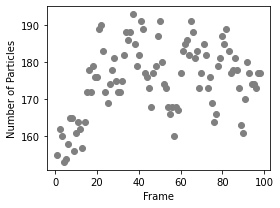

In [5]:
#plot the number of particles in each frame
fig,ax = plt.subplots(1,1,figsize=(4,3))
data_clean_sort = data_clean.sort_values(by = 'frame')
for i in range(data_clean_sort['frame'].max()):
    data_frame = data_clean_sort[data_clean_sort['frame'] == i]
    if len(data_frame) > 0:
        ax.plot(i,len(data_frame),'o',color = 'grey')
#
FrameNumber = data_clean_sort['frame'].max()-data_clean_sort['frame'].min()
MinFrame = data_clean_sort['frame'].min()
ax.set_xlabel('Frame')
ax.set_ylabel('Number of Particles')
fig.tight_layout()


0           1
1           1
2           1
3           1
4           1
         ... 
22479    1459
22481    1459
22519    1459
22520    1459
22531    1459
Name: particle, Length: 17349, dtype: int64
    condition  sample_id  track_id     t           y           x          id  \
248  1-2Pulse  1-2Pulse1        12   9.0 -297.972831 -460.823193  10000018.0   
249  1-2Pulse  1-2Pulse1        12   8.0 -294.972831 -456.823193   9000015.0   
250  1-2Pulse  1-2Pulse1        12   1.0 -269.972831 -449.823193   2000016.0   
252  1-2Pulse  1-2Pulse1        12  11.0 -302.972831 -457.823193  12000011.0   
253  1-2Pulse  1-2Pulse1        12   5.0 -283.972831 -445.823193   6000013.0   

     parent_track_id   parent_id  particle  frame         vx         vy  \
248               -1   9000015.0        12      9 -24.096386 -18.072289   
249               -1   8000018.0        12      8 -30.120482 -30.120482   
250               -1   1000015.0        12      1   0.000000   0.000000   
252               -1 

/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_61720/3835397516.py:28: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  plt.colorbar(ax[1].collections[0],label='Frame (normalized)')


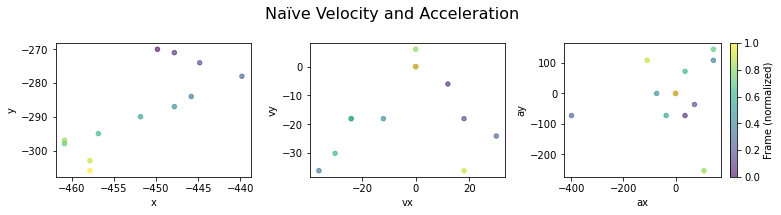

In [6]:
# plotting some acceleration data
#get particle 1
print(data_clean['particle'])

data_1particle = data_clean[data_clean['particle'] == 12]
print(data_1particle.head())

fig,ax = plt.subplots(1,3,figsize=(11,3))
cmap = plt.cm.viridis
normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                    (data_1particle['frame'].max() - data_1particle['frame'].min())
ax[0].scatter(data_1particle['x'],data_1particle['y'],
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].scatter(data_1particle['vx'],data_1particle['vy'],
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[1].set_xlabel('vx')
ax[1].set_ylabel('vy')
ax[2].scatter(data_1particle['ax'], data_1particle['ay'], 
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[2].set_xlabel('ax')
ax[2].set_ylabel('ay')
# ax[1].set_ylim([-2,2])
# ax[1].set_xlim([-2,2])
# ax[0].set_ylim([-1.2,1.2])
# ax[0].set_xlim([-1.2,1.2])
plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
#ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
# put central title for whole figure
if T_Naive:
    fig.suptitle('Naïve Velocity and Acceleration', fontsize=16)
else:
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau =$'+str(tau), fontsize=16)
fig.tight_layout()
scale = 1
if T_weak and T_Naive:
    fig,ax = plt.subplots(1,2,figsize=(8,3))
    cmap = plt.cm.viridis
    normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                        (data_1particle['frame'].max() - data_1particle['frame'].min())
    ax[0].scatter(np.multiply(data_1particle['Wvx'],scale),np.multiply(data_1particle['Wvy'],scale),
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    ax[0].set_xlabel('Wvx')
    ax[0].set_ylabel('Wvy')
    ax[1].scatter(data_1particle['Wax'], data_1particle['Way'], 
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    print(data_1particle['Wax'])
    ax[1].set_xlabel('Wax')
    ax[1].set_ylabel('Way')
    plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
    #ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
    # put central title for whole figure
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau = $'+str(tau), fontsize=16)
    fig.tight_layout()
    ax[1].set_xlabel('ax')
    ax[1].set_ylabel('ay')
    ax[1].set_ylim([-2,2])
    ax[1].set_xlim([-2,2])
    ax[0].set_ylim([-1.2,1.2])
    ax[0].set_xlim([-1.2,1.2])

In [7]:
# Prepare datast with graph structure
cell_radius = 10.0
N_neighbours = 10
r_cut = cell_radius * N_neighbours
useNeighborList = True
dataset = prepare_dataset(data_clean,cutoff=cell_radius*N_neighbours,max_frames=600,use_neighbor_list=useNeighborList,n_boxes=8,neighbor_rebuild_interval=5,neighbor_domain_margin=5)

Preparing dataset from 99 frames...
processing frame  1
processing frame  2
processing frame  3
processing frame  4
processing frame  5
processing frame  6
processing frame  7
processing frame  8
processing frame  9
processing frame  10
processing frame  11
processing frame  12
processing frame  13
processing frame  14
processing frame  15
processing frame  16
processing frame  17
processing frame  18
processing frame  19
processing frame  20
processing frame  21
processing frame  22
processing frame  23
processing frame  24
processing frame  25
processing frame  26
processing frame  27
processing frame  28
processing frame  29
processing frame  30
processing frame  31
processing frame  32
processing frame  33
processing frame  34
processing frame  35
processing frame  36
processing frame  37
processing frame  38
processing frame  39
processing frame  40
processing frame  41
processing frame  42
processing frame  43
processing frame  44
processing frame  45
processing frame  46
process

n_neighbors_arr shape: (17349,)
n_neighbors range: 0.0 to 44.0
nn_r_arr shape: (17285,)
nn_r range: 1.000000 to 98.270035
44
Number of points with no neighbors 64


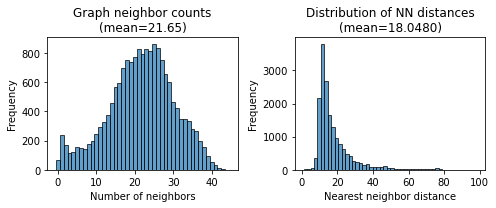

In [9]:
# Flatten n_neighbors_arr (it's a list of arrays, one per frame)
n_neighbors_arr = np.concatenate([d['num_neighbors'] for d in dataset])
print(f"n_neighbors_arr shape: {n_neighbors_arr.shape}")
print(f"n_neighbors range: {n_neighbors_arr.min()} to {n_neighbors_arr.max()}")

#Flatten nn_r_arr (it's now an array per frame, one value per node)
nn_r_arr = np.concatenate([d['nn_r'] for d in dataset])
#Remove NaN values (nodes with no neighbors)
nn_r_arr = nn_r_arr[~np.isnan(nn_r_arr)]
print(f"nn_r_arr shape: {nn_r_arr.shape}")
print(f"nn_r range: {nn_r_arr.min():.6f} to {nn_r_arr.max():.6f}")

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

# Histogram of number of neighbors (use integer bins)
n_neighbors_max = int(n_neighbors_arr.max())
print(n_neighbors_max)
ax[0].hist(n_neighbors_arr, bins=np.arange(-0.5, n_neighbors_max + 1.5, 1), edgecolor='black', alpha=0.7)
ax[0].set_xlabel("Number of neighbors")
ax[0].set_ylabel("Frequency")
ax[0].set_title(f"Graph neighbor counts\n(mean={n_neighbors_arr.mean():.2f})")

# Histogram of nearest neighbor distance
ax[1].hist(nn_r_arr, bins=50, edgecolor='black', alpha=0.7)
ax[1].set_xlabel("Nearest neighbor distance")
ax[1].set_ylabel("Frequency")
ax[1].set_title(f"Distribution of NN distances\n(mean={nn_r_arr.mean():.4f})")

print("Number of points with no neighbors",np.sum(n_neighbors_arr == 0))

fig.tight_layout()
plt.show()

## Step 2: Build Graph Dataset


In [11]:
#Split into train/val/test
train_frac = 0.7
val_frac = 0.15
test_frac = 0.15
# max_frame = max(d['frame'] for d in dataset_loaded)
# dataset_loaded_last25 = [d for d in dataset_loaded if d['frame'] > max_frame - 25]
train_data_, val_data_, test_data_, all_data_ = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac)
#print(train_data)

# train_data_0,val_data_0,test_data_0 = split_dataset(dataset_first25, train_frac = train_frac,val_frac=val_frac)
# train_data_1,val_data_1,test_data_1 = split_dataset(dataset_25_1, train_frac = train_frac,val_frac=val_frac)
# train_data_2,val_data_2,test_data_2 = split_dataset(dataset_25_2, train_frac = train_frac,val_frac=val_frac)
# train_data_3,val_data_3,test_data_3 = split_dataset(dataset_25_3, train_frac = train_frac,val_frac=val_frac)
# train_data_4,val_data_4,test_data_4 = split_dataset(dataset_25_4, train_frac = train_frac,val_frac=val_frac)
# train_data_5,val_data_5,test_data_5 = split_dataset(dataset_25_5, train_frac = train_frac,val_frac=val_frac)


Data splits:
  Train: 69
  Val:   14
  Test:  16


len(edges) 3860
i 0
i 1000
i 2000
i 3000


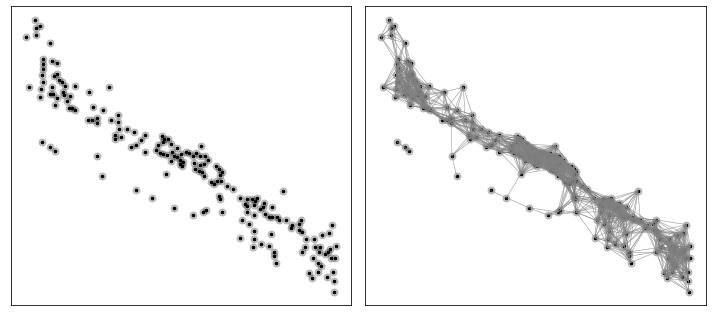

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
# Get first frame from train_data
frame_data = all_data_ [50]  # Fixed: get first element of list

# Plot edges on second subplot
edges = frame_data['edges']
print("len(edges)",edges.shape[1])
for i in range(int(edges.shape[1])):
    if i%1000 == 0:
        print("i",i)

    source_idx = edges[0, i]
    target_idx = edges[1, i]
    
    # Get positions
    x_source, y_source = frame_data['nodes'][source_idx][:2] #first two node features are position
    x_target, y_target = frame_data['nodes'][target_idx][:2]
    
    # Plot line from source to target
    ax[1].plot([x_source, x_target], 
               [y_source, y_target], 
               color='gray', alpha=0.5, linewidth=0.5)

for i in range(2):
    ax[i].scatter(frame_data['nodes'][:, 0], frame_data['nodes'][:, 1], 
                  color='black', s=7)
    ax[i].scatter(frame_data['nodes'][:, 0], frame_data['nodes'][:, 1], 
                  color='black',alpha = 0.2, s=50)
    #ax[i].set_xlabel(r'x [$\mu$ m]')
    #ax[i].set_ylabel(r'y [$\mu$ m]')
ax[0].set_yticks([])
ax[1].set_yticks([])
ax[0].set_xticks([])
ax[1].set_xticks([])
#ax[0].set_title('Nodes only')
#ax[1].set_title('Graph (N=4 cell diameters)')
ax[1].invert_yaxis()
ax[0].invert_yaxis()
fig.tight_layout()
plotname = "Plots/Graph_Schematics.png"
#fig.savefig(plotname,dpi=600)
